# Introduction

In [34]:
import numpy as np
import csv
import pandas as pd
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

# Problem I

## Problem I.1
Linear Regression

In [2]:
def make_Phi(data,m):
    Phi = []
    for row in data:
        # construct row features
        Phi.append(make_Phi_row(row[:-1],m)) 
    return Phi

def make_Phi_row(x,m):
    Phi_row = []
    for j in x:
        for i in range(m):
            Phi_row.append(j**(i + 1))    
    Phi_row.append(1)
    return Phi_row
    
    


In [3]:
# import csv files
# Import the training data
flight_data_train = np.loadtxt('flight_data_train.csv', delimiter = ',')
# Import the testing data
flight_data_test = np.loadtxt('flight_data_test.csv', delimiter = ',')

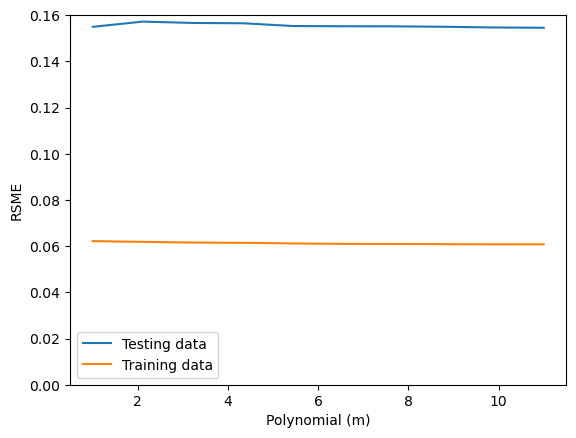

In [59]:
# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize = (flight_data_train - minTrain)/(maxTrain - minTrain)

minTest = np.min(flight_data_test,axis = 0)
maxTest = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest)/(maxTest - minTest)

trainingError = []
testingError = []

for m in range(10):
    m += 1
    # Build matrix Phi
    Phi_train = make_Phi(train_normalize,m)
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    
    # Calculate weights
    weights = np.matmul(np.linalg.pinv(Phi_train),tTrain);
    
    # Test accuracy 
    Phi_test = make_Phi(test_normalize,m)
    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest = np.matmul(Phi_test,weights) 

    # Calculate training and test error
    trainingError.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingError.append(  np.sqrt(np.square(yTest -tTest).mean() ) )
#     plt.plot(yTrain)
# plt.plot(tTest)
    
# Plot results
plt.figure()
plt.plot(np.linspace(1,m+1,m),testingError, label = 'Testing data')
plt.plot(np.linspace(1,m+1,m),trainingError, label = 'Training data')
plt.ylim([0,0.16])
plt.xlabel("Polynomial (m)")
plt.ylabel("RSME")
plt.legend()
plt.show()

## Problem 1.2
Ridge Regression

In [30]:
np.size(Phi_train[0])

13

100%|██████████| 37/37 [00:06<00:00,  5.83it/s]


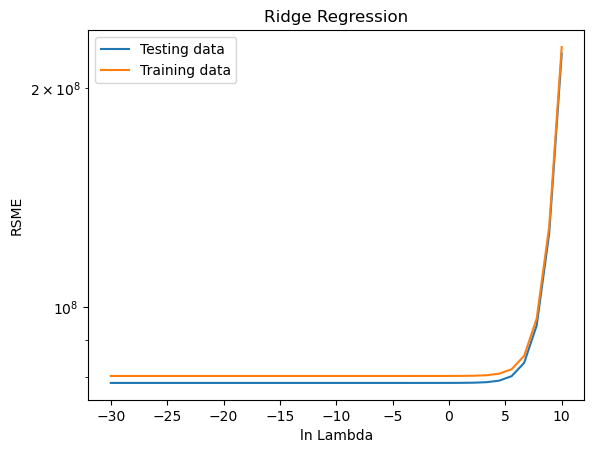

In [61]:
# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize = (flight_data_train - minTrain)/(maxTrain - minTrain)

minTest = np.min(flight_data_test,axis = 0)
maxTest = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest)/(maxTest - minTest)

trainingError = []
testingError = []

poly_range = 6

# Build lambda values:
ln_lambda_vals = np.linspace(-30,10,poly_range * (np.size(train_normalize[0]) - 1) + 1)
lambda_vals = np.exp(ln_lambda_vals)


for lambda_val in tqdm(lambda_vals):
    
    # Build matrix Phi
    Phi_train = make_Phi(train_normalize,m)
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    
    # Calculate weights
    weights = lambda_val * np.identity(np.size(Phi_train[0])) + np.matmul(np.transpose(Phi_train),Phi_train)
    weights = np.matmul(np.matmul(weights,np.transpose(Phi_train)),tTrain);
    
    # Test accuracy 
    Phi_test = make_Phi(test_normalize,m)
    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest = np.matmul(Phi_test,weights) 

    # Calculate training and test error
    trainingError.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingError.append(  np.sqrt(np.square(yTest -tTest).mean() ) )
    
# Plot results
plt.plot(ln_lambda_vals,testingError, label = 'Testing data')
plt.plot(ln_lambda_vals,trainingError, label = 'Training data')
plt.yscale('log')
plt.xlabel("ln Lambda")
plt.ylabel("RSME")
plt.title("Ridge Regression")
plt.legend()
plt.show()